In [1]:
import gymnasium_env as drausp_env
import numpy as np
from pathlib import Path

from instance_reader import get_instance_data
import matplotlib.pyplot as plt

data_path = Path("../instances/lion18s/SA01.txt")

In [2]:
DRAUSP_data = get_instance_data(data_path)

K = DRAUSP_data.num_slots
T_d = DRAUSP_data.num_requests
C_k = DRAUSP_data.capacity_vector
instance = DRAUSP_data.instance
print(K)
print(T_d)
print(C_k)
print(instance)

4
50
[10, 10, 10, 10]
[[41, 1, 1, 0, 0], [39, 1, 1, 0, 0], [20, 1, 3, 0, 0], [61, 2, 1, 0, 0], [18, 2, 1, 0, 0], [23, 1, 4, 0, 0], [25, 1, 1, 0, 0], [13, 1, 1, 0, 0], [77, 1, 1, 0, 0], [8, 1, 2, 0, 0], [25, 1, 3, 0, 0], [74, 1, 1, 0, 0], [39, 1, 3, 0, 0], [54, 3, 2, 0, 0], [70, 1, 3, 0, 0], [71, 1, 1, 0, 0], [55, 1, 1, 0, 0], [9, 1, 1, 0, 0], [96, 1, 1, 0, 0], [63, 3, 2, 0, 0], [50, 3, 2, 0, 0], [20, 1, 1, 0, 0], [43, 1, 2, 0, 0], [74, 1, 2, 0, 0], [62, 1, 1, 0, 0], [60, 1, 1, 0, 0], [22, 1, 1, 0, 0], [81, 1, 2, 0, 0], [92, 1, 1, 0, 0], [80, 1, 1, 0, 0], [38, 2, 1, 0, 0], [84, 1, 1, 0, 0], [39, 1, 2, 0, 0], [88, 2, 1, 0, 0], [69, 1, 3, 0, 0], [21, 2, 1, 0, 0], [15, 1, 1, 0, 0], [47, 3, 1, 0, 0], [67, 1, 1, 0, 0], [18, 1, 1, 0, 0], [87, 1, 1, 0, 0], [58, 1, 2, 0, 0], [34, 2, 1, 0, 0], [8, 1, 1, 0, 0], [97, 1, 1, 0, 0], [73, 1, 1, 0, 0], [54, 1, 1, 0, 0], [69, 2, 1, 0, 0], [79, 1, 2, 0, 0], [9, 1, 2, 0, 0]]


In [3]:
env = drausp_env.DrauspEnv(K=K, T_d=T_d, C_k=C_k, instance=instance, render_mode="human")

In [4]:
from dqn_agent import DQNAgent
from lattice_dqn import LatticeDQNNetwork
agent = DQNAgent(env, QnetworkClass=LatticeDQNNetwork)

In [5]:
reward_history, monotonicity_violations = agent.train(num_episodes=1000)

  Systematic monotonicity (Episode 1): C_k: 0.0%, t: 58.2%, r: 31.0%, q: 16.5%, mixed: 0.0%
  Systematic monotonicity (Episode 2): C_k: 0.0%, t: 58.2%, r: 31.0%, q: 16.5%, mixed: 0.0%
  Systematic monotonicity (Episode 3): C_k: 0.0%, t: 58.2%, r: 31.0%, q: 16.5%, mixed: 0.0%
  Systematic monotonicity (Episode 4): C_k: 0.0%, t: 58.2%, r: 31.0%, q: 16.5%, mixed: 0.0%
  Systematic monotonicity (Episode 5): C_k: 0.0%, t: 58.2%, r: 31.0%, q: 16.5%, mixed: 0.0%
  Systematic monotonicity (Episode 6): C_k: 0.0%, t: 58.2%, r: 31.0%, q: 16.5%, mixed: 0.0%
  Systematic monotonicity (Episode 7): C_k: 0.0%, t: 58.2%, r: 31.0%, q: 16.5%, mixed: 0.0%
  Systematic monotonicity (Episode 8): C_k: 0.0%, t: 58.2%, r: 31.0%, q: 16.5%, mixed: 0.0%
  Systematic monotonicity (Episode 9): C_k: 0.0%, t: 58.2%, r: 31.0%, q: 16.5%, mixed: 0.0%
Ich trainiere...
  Systematic monotonicity (Episode 10): C_k: 0.0%, t: 57.7%, r: 52.5%, q: 12.0%, mixed: 21.9%
Ich trainiere...
Ich trainiere...
Ich trainiere...
Ich traini

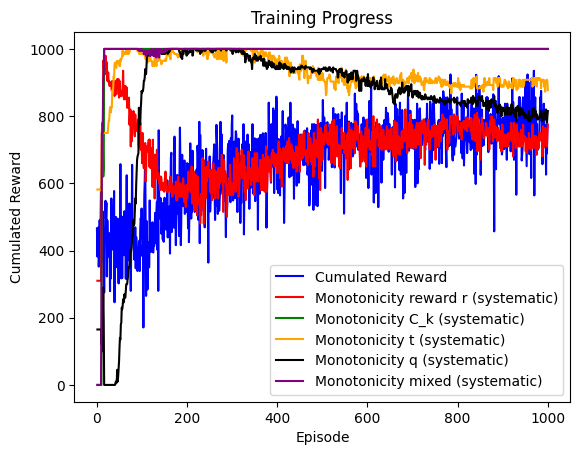

In [6]:
episodes = [x[0] for x in monotonicity_violations]
mono_c   = [x[1] * 1000 for x in monotonicity_violations]
mono_t   = [x[2] * 1000 for x in monotonicity_violations]
mono_r   = [x[3] * 1000 for x in monotonicity_violations]
mono_q   = [x[4] * 1000 for x in monotonicity_violations]
mono_mixed = [x[5] * 1000 for x in monotonicity_violations]

plt.plot(reward_history, color="blue", label="Cumulated Reward")
plt.plot(episodes, mono_r,  color="red",    label="Monotonicity reward r (systematic)")
plt.plot(episodes, mono_c, color="green",  label="Monotonicity C_k (systematic)")
plt.plot(episodes, mono_t, color="orange", label="Monotonicity t (systematic)")
plt.plot(episodes, mono_q, color="black",   label="Monotonicity q (systematic)")
plt.plot(episodes, mono_mixed, color="purple", label="Monotonicity mixed (systematic)")
plt.xlabel("Episode")
plt.ylabel("Cumulated Reward")
plt.title("Training Progress")
plt.legend()
plt.show()

In [7]:
import torch
net = agent.policy_net
net.eval()
obs, _ = env.reset()
print("Initial observation:", obs)
obs = [3,6,7,4,3,41,1,1,0,0]
modified_obs = obs.copy()
modified_obs[1:5] = [10,10,10,10]  
obs = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
modified_obs_t = torch.tensor(modified_obs, dtype=torch.float32).unsqueeze(0)
with torch.no_grad():
    q_values = net(obs)
    print("Q-values for initial state:", q_values)  
    q_values_modified = net(modified_obs_t)
    print("Q-values for modified state:", q_values_modified)

Initial observation: [ 1. 10. 10. 10. 10. 41.  1.  1.  0.  0.]
Q-values for initial state: tensor([[172.3363, 203.2483, 196.3305, 201.5014,  32.4838]])
Q-values for modified state: tensor([[271.6414, 307.7566, 300.6707, 305.8021,  45.1001]])


In [8]:
obs, _ = env.reset()
obs = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
done = False
cumulated_reward = 0.0

while not done:
                # 1. Aktion wählen
                action = net(obs)
                action = torch.argmax(action, dim=1).item()  # Greedy Aktion
                # 2. Umgebungsschritt
                next_obs, reward, terminated, truncated, _ = env.step(action)
                done = terminated or truncated

                obs = next_obs
                obs = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
                cumulated_reward += reward
print(cumulated_reward)

348.0


In [9]:
import torch

net = agent.policy_net
K = net.K

# Einen echten State holen
obs, _ = env.reset()
obs = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)

with torch.no_grad():
    q_dqn   = net.dqn(obs)
    q_total = net(obs)
    bonus   = q_total - q_dqn

print(f"Q_dqn:   {q_dqn.numpy().flatten()}")
print(f"Bonus:   {bonus.numpy().flatten()[0]:.3f}")
print(f"Q_total: {q_total.numpy().flatten()}")

Q_dqn:   [273.7967   305.18582  299.63174  304.91003   46.852375]
Bonus:   -2.315
Q_total: [271.4818   302.87094  297.31686  302.59515   44.537506]


Teste ob der Bonus einen wirklichen Einfluss hat

In [10]:
import torch

net = agent.policy_net
K = net.K

# Einen echten State holen
obs, _ = env.reset()
obs = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)

with torch.no_grad():
    q_dqn   = net.dqn(obs)
    q_total = net(obs)
    bonus   = q_total - q_dqn

print(f"Q_dqn:   {q_dqn.numpy().flatten()}")
print(f"Bonus:   {bonus.numpy().flatten()[0]:.3f}")
print(f"Q_total: {q_total.numpy().flatten()}")

Q_dqn:   [273.7967   305.18582  299.63174  304.91003   46.852375]
Bonus:   -2.315
Q_total: [271.4818   302.87094  297.31686  302.59515   44.537506]


Bonus erfüllt die Monotonieeigenschaft

In [11]:
for c_val in [0.0, 5.0, 10.0]:
    c_raw = torch.tensor([[c_val] * K], dtype=torch.float32)
    with torch.no_grad():
        c_cal = torch.cat(
            [cal(c_raw[:, k:k+1].double()).float()
             for k, cal in enumerate(net.c_calibrators)],
            dim=1,
        )
        bonus = net.c_lattice(c_cal.double()).float().item()
    print(f"C_k = {c_val:.0f}  →  Bonus = {bonus:.3f}")

C_k = 0  →  Bonus = 3.353
C_k = 5  →  Bonus = 2.128
C_k = 10  →  Bonus = -2.315
